# Error Analysis: Visual Comparision `Viewer`


Visualize a prediction sample from the evaluation results.

This function reads a specific row from `evaluation_results.csv` and
displays three images side-by-side for easy error analysis:

1. The original input image from the dataset
2. The molecular structure generated from the target SMILES
3. The molecular structure generated from the predicted SMILES

It also prints the target SMILES, predicted SMILES, and whether the
prediction matches the ground truth.

Parameters
----------
row_id : int
    The row index from `evaluation_results.csv` corresponding to the
    sample to visualize.

Output
------
Displays the original image, the target molecule, and the predicted
molecule using RDKit visualization, and prints the SMILES strings
along with the match status.

Example
-------
show_sample(10)


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from rdkit import Chem
from rdkit.Chem import Draw
import textwrap

CSV_FILE = "evaluation_results.csv"
df = pd.read_csv(CSV_FILE)


def wrap_smiles(smiles, width=35):
    """Wrap long SMILES strings and handle NaN."""
    if pd.isna(smiles):
        return "NaN"
    return "\n".join(textwrap.wrap(str(smiles), width))


def show_sample(row_id):

    row = df.iloc[row_id]

    image_path = row["image"]
    target = row["target"]
    prediction = row["prediction"]
    match = row["match"]

    img = Image.open(image_path)

    # Safe molecule conversion
    target_mol = Chem.MolFromSmiles(str(target)) if pd.notna(target) else None
    pred_mol = Chem.MolFromSmiles(str(prediction)) if pd.notna(prediction) else None

    target_img = Draw.MolToImage(target_mol, size=(300,300)) if target_mol else None
    pred_img = Draw.MolToImage(pred_mol, size=(300,300)) if pred_mol else None

    fig, axs = plt.subplots(1, 3, figsize=(15,6))

    # ---------- Original Image ----------
    axs[0].imshow(img)
    axs[0].set_title("Original Image", fontsize=12)
    axs[0].axis("off")

    # ---------- Target ----------
    axs[1].set_title("Target", fontsize=12)
    axs[1].axis("off")

    if target_img:
        axs[1].imshow(target_img)

    axs[1].text(
        0.5, -0.15,
        wrap_smiles(target),
        ha="center",
        va="top",
        fontsize=9,
        transform=axs[1].transAxes
    )

    # ---------- Prediction ----------
    axs[2].set_title("Prediction", fontsize=12)
    axs[2].axis("off")

    if pd.isna(prediction):
        axs[2].text(
            0.5, 0.5,
            "NaN",
            ha="center",
            va="center",
            fontsize=20,
            color="red",
            transform=axs[2].transAxes
        )
    else:
        if pred_img:
            axs[2].imshow(pred_img)

        axs[2].text(
            0.5, -0.15,
            wrap_smiles(prediction),
            ha="center",
            va="top",
            fontsize=9,
            transform=axs[2].transAxes
        )

    # ---------- Global title ----------
    color = "green" if match else "red"

    fig.suptitle(
        f"RowID : {row_id}  |  Match: {match}",
        fontsize=15,
        color=color
    )

    plt.subplots_adjust(bottom=0.25, wspace=0.25)
    plt.show()

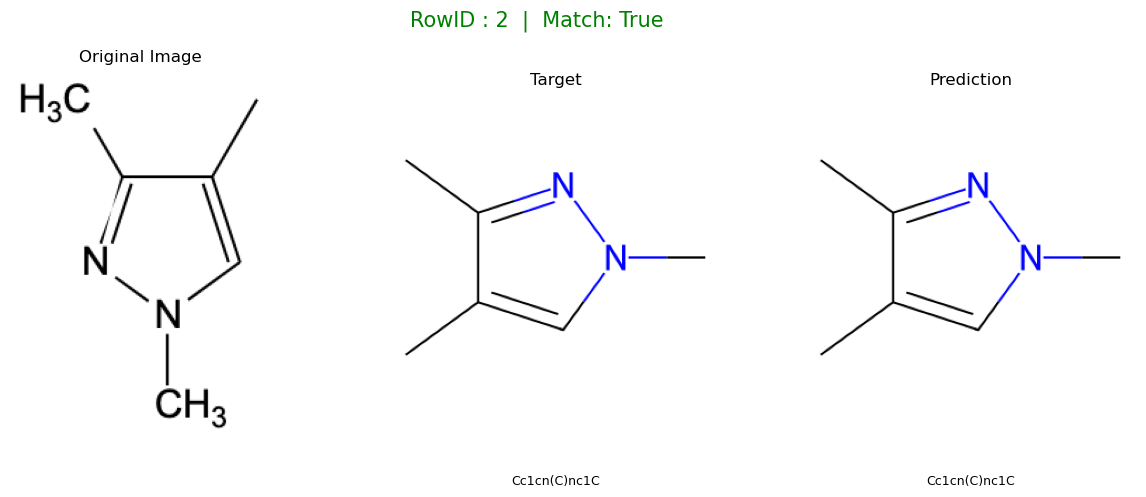

In [6]:
# pass row_id to visualize
show_sample(2)

# Error Analysis : Visual Comparision `Script`
Generate visual comparison images for model predictions and organize them
based on correctness.

For each row in `evaluation_results.csv`, the script creates a visualization
containing three panels:

1. The original input image from the dataset
2. The molecular structure generated from the target SMILES
3. The molecular structure generated from the predicted SMILES

If the prediction is missing (NaN), the prediction panel displays the text
"NaN" instead of a molecule image.

The visualization also includes:
- The wrapped SMILES strings below the target and prediction molecules
- The row index and match status as the figure title
- Green title color if the prediction is correct
- Red title color if the prediction is incorrect

Each generated visualization is saved to one of two directories:

- `correct/`   : contains images where the prediction matches the target
- `incorrect/` : contains images where the prediction does not match

This allows quick visual inspection of correct and incorrect predictions
for error analysis of the chemical OCR model.


In [ ]:
import os
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from rdkit import Chem
from rdkit.Chem import Draw
import textwrap
from rdkit import RDLogger
RDLogger.DisableLog('rdApp.*')

CSV_FILE = "evaluation_results.csv"

CORRECT_DIR = "correct"
INCORRECT_DIR = "incorrect"

os.makedirs(CORRECT_DIR, exist_ok=True)
os.makedirs(INCORRECT_DIR, exist_ok=True)

df = pd.read_csv(CSV_FILE)


def wrap_smiles(smiles, width=35):
    if pd.isna(smiles):
        return "NaN"
    return "\n".join(textwrap.wrap(str(smiles), width))


def save_visualization(row_id):

    row = df.iloc[row_id]

    image_path = row["image"]
    target = row["target"]
    prediction = row["prediction"]
    match = row["match"]

    img = Image.open(image_path)

    target_mol = Chem.MolFromSmiles(str(target))
    pred_mol = None if pd.isna(prediction) else Chem.MolFromSmiles(str(prediction))

    target_img = Draw.MolToImage(target_mol, size=(300,300)) if target_mol else None
    pred_img = Draw.MolToImage(pred_mol, size=(300,300)) if pred_mol else None

    fig, axs = plt.subplots(1,3, figsize=(15,6))

    # Original image
    axs[0].imshow(img)
    axs[0].set_title("Original")
    axs[0].axis("off")

    # Target
    if target_img:
        axs[1].imshow(target_img)

    axs[1].set_title("Target")
    axs[1].axis("off")

    axs[1].text(
        0.5, -0.15,
        wrap_smiles(target),
        ha="center",
        va="top",
        fontsize=9,
        transform=axs[1].transAxes
    )

    # Prediction
    axs[2].set_title("Prediction")
    axs[2].axis("off")

    if pred_img:
        axs[2].imshow(pred_img)

        axs[2].text(
            0.5, -0.15,
            wrap_smiles(prediction),
            ha="center",
            va="top",
            fontsize=9,
            transform=axs[2].transAxes
        )

    else:
        axs[2].text(
            0.5, 0.5,
            "NaN",
            ha="center",
            va="center",
            fontsize=20,
            color="red",
            transform=axs[2].transAxes
        )

    color = "green" if match else "red"

    fig.suptitle(
        f"Row {row_id} | Match: {match}",
        fontsize=14,
        color=color
    )

    plt.subplots_adjust(bottom=0.25)

    # choose folder
    folder = CORRECT_DIR if match else INCORRECT_DIR
    save_path = os.path.join(folder, f"{row_id}.png")

    plt.savefig(save_path, bbox_inches="tight")
    plt.close()


for i in range(len(df)):
    print(f"Processing {i}/{len(df)}")
    save_visualization(i)